In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
pg_user = "postgres"
pg_pass = "postgres"
pg_host = "localhost"
pg_port = "5432"
pg_db   = "geologia"

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
)

gamma_cols = [
    "ctcor", "ctcor_n", "ctcor_np",
    "kperc", "kperc_n", "kperc_np",
    "eu",    "eu_n",    "eu_np",
    "eth",   "eth_n",   "eth_np",
    'thk_razao','uth_razao','uk_razao',
]

loc_cols = [
    'x', 'y', 'mdt',
    'lat', 'lon',
    'temp', 'sample_id', 'line_id','survey_code',
]

sql = f"""
SELECT {", ".join(gamma_cols + loc_cols)}
FROM geof.v_gamma_1082_corr_mean_total
"""


In [3]:
!fastfetch

                  -`
                 .o+`
                `ooo/
               `+oooo:
              `+oooooo:
              -+oooooo+:
            `/:-:++oooo+:
           `/++++/+++++++:
          `/++++++++++++++:
         `/+++ooooooooooooo/`
        ./ooosssso++osssssso+`
       .oossssso-````/ossssss+`
      -osssssso.      :ssssssso.
     :osssssss/        osssso+++.
    /ossssssss/        +ssssooo/-
  `/ossssso+/:-        -:/+osssso+-
 `+sso+:-`                 `.-/+oso:
`++:.                           `-/+/
.`                                 `/ggrl@GeoServer
--------------
OS: Arch Linux x86_64
Host: B450M DS3H
Kernel: Linux 6.12.57-1-lts
Uptime: 3 days, 14 hours, 8 mins
Packages: 1326 (pacman)
Shell: ipykernel_launcher
Display (912Vwa): 1440x900 in 19", 60 Hz [External]
WM: Hyprland unknown (Wayland)
Cursor: Adwaita
Terminal: jupyter-lab
CPU: AMD Ryzen 5 3600X (12) @ 4.41 GHz
GPU: NVIDIA GeForce GTX 1650 SUPER [Discrete]
Memory: 25.72 GiB / 39.12 GiB (66%)
Swap: Disabled
Dis

In [4]:
df = pd.read_sql(sql, engine)

In [5]:
gamma_cols = [
 'ctcor_np',
 'kperc_np',
 'eu_np',
 'eth_np',
 'thk_razao',
 'uth_razao',
 'uk_razao']

In [6]:
percentiles = [0.005, 0.01, 0.1, 0.25, 0.5, 0.75, 0.99, 0.995]
df[gamma_cols].describe(percentiles).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,99%,99.5%,max
ctcor_np,1391553.0,1129.681691,646.366075,0.009,109.70912,112.874368,481.877200,686.753,980.697,1418.631,3210.22336,3544.21484,23003.802
kperc_np,1391553.0,0.367328,0.311677,0.000,0.00600,0.012000,0.054000,0.158,0.298,0.481,1.52600,1.77300,3.858
eu_np,1391553.0,1.222016,1.011404,0.000,0.02100,0.042000,0.117585,0.471,1.028,1.700,4.64600,5.36300,15.441
eth_np,1391553.0,16.299985,9.942545,0.000,0.74600,1.629517,6.605000,9.490,13.794,20.548,49.15700,54.67724,367.673
thk_razao,1391560.0,75.686857,125.920439,0.000,0.00000,0.000000,10.511000,21.081,40.116,80.405,618.48904,830.83925,5289.850
uth_razao,1391560.0,0.079719,0.064690,0.000,0.00000,0.000000,0.011000,0.039,0.069,0.106,0.30500,0.37100,3.900
uk_razao,1391560.0,5.105412,8.664511,0.000,0.00000,0.000000,0.000000,1.143,2.871,5.706,42.21241,57.08100,378.381


In [7]:
import numpy as np
import verde as vd
import time

# ---------------------------------------------
# Dados: coordenadas projetadas e uma variável
# ---------------------------------------------
x = df["x"].values
y = df["y"].values
coords = (x, y)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1391560 entries, 0 to 1391559
Data columns (total 24 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   ctcor        1391553 non-null  float64
 1   ctcor_n      1391553 non-null  float64
 2   ctcor_np     1391553 non-null  float64
 3   kperc        1391553 non-null  float64
 4   kperc_n      1391553 non-null  float64
 5   kperc_np     1391553 non-null  float64
 6   eu           1391553 non-null  float64
 7   eu_n         1391553 non-null  float64
 8   eu_np        1391553 non-null  float64
 9   eth          1391553 non-null  float64
 10  eth_n        1391553 non-null  float64
 11  eth_np       1391553 non-null  float64
 12  thk_razao    1391560 non-null  float64
 13  uth_razao    1391560 non-null  float64
 14  uk_razao     1391560 non-null  float64
 15  x            1391560 non-null  float64
 16  y            1391560 non-null  float64
 17  mdt          1391560 non-null  float64
 18  la

In [9]:
'''
import numpy as np
import pandas as pd
import verde as vd  # já traz vd.median_distance

# Coordenadas em metros (já projetadas)
coords = (
    df["x"].to_numpy(),
    df["y"].to_numpy(),
)

k_max = 200
rows = []

for k in range(1, k_max + 1):
    # distância mediana até os k vizinhos de CADA ponto
    dist_k = vd.median_distance(coords, k_nearest=k)

    # um único valor de espaçamento característico para o conjunto
    d_med = np.median(dist_k)

    rows.append((k, d_med))
    #print(f"k = {k:3d}  ->  d_med_m = {d_med:.3f}")

# DataFrame final k × distância_mediana
df_knn = pd.DataFrame(rows, columns=["k", "d_med_m"])

# Espaçamento nominal entre linhas de voo (m)
line_spacing = 500.0

# df_knn já contém as colunas "k" e "d_med_m"

# 1) Variação absoluta da distância mediana entre k e k-1
df_knn["delta_d"] = df_knn["d_med_m"].diff()  # Na linha k=1 fica NaN

# 2) Variação relativa (taxa de crescimento)
df_knn["rel_delta"] = df_knn["delta_d"] / df_knn["d_med_m"].shift(1)

# 3) Diferença em relação aos 500 m (e valor absoluto)
df_knn["diff_to_500"] = df_knn["d_med_m"] - line_spacing
df_knn["abs_diff_500"] = df_knn["diff_to_500"].abs()

# Opcional: razão em relação ao espaçamento teórico
df_knn["ratio_to_500"] = df_knn["d_med_m"] / line_spacing
'''
#df_knn.to_csv('./knn_mean_dist_1082.csv')

'\nimport numpy as np\nimport pandas as pd\nimport verde as vd  # já traz vd.median_distance\n\n# Coordenadas em metros (já projetadas)\ncoords = (\n    df["x"].to_numpy(),\n    df["y"].to_numpy(),\n)\n\nk_max = 200\nrows = []\n\nfor k in range(1, k_max + 1):\n    # distância mediana até os k vizinhos de CADA ponto\n    dist_k = vd.median_distance(coords, k_nearest=k)\n\n    # um único valor de espaçamento característico para o conjunto\n    d_med = np.median(dist_k)\n\n    rows.append((k, d_med))\n    #print(f"k = {k:3d}  ->  d_med_m = {d_med:.3f}")\n\n# DataFrame final k × distância_mediana\ndf_knn = pd.DataFrame(rows, columns=["k", "d_med_m"])\n\n# Espaçamento nominal entre linhas de voo (m)\nline_spacing = 500.0\n\n# df_knn já contém as colunas "k" e "d_med_m"\n\n# 1) Variação absoluta da distância mediana entre k e k-1\ndf_knn["delta_d"] = df_knn["d_med_m"].diff()  # Na linha k=1 fica NaN\n\n# 2) Variação relativa (taxa de crescimento)\ndf_knn["rel_delta"] = df_knn["delta_d"] / df

In [44]:
df_knn = pd.read_csv(
    "./knn_mean_dist_1082.csv",
    index_col="k",                      # usa a coluna k como índice
    usecols=lambda c: c != "Unnamed: 0" # ignora a coluna Unnamed: 0
)

In [45]:
df_knn

,d_med_m,delta_d,rel_delta,diff_to_500,abs_diff_500,ratio_to_500
k,,,,,,
1,77.000000,NaN,NaN,-423.000000,423.000000,0.154000
2,77.003247,0.003247,0.000042,-422.996753,422.996753,0.154006
3,77.025970,0.022723,0.000295,-422.974030,422.974030,0.154052
4,115.053824,38.027854,0.493702,-384.946176,384.946176,0.230108
5,153.029409,37.975585,0.330068,-346.970591,346.970591,0.306059
...,...,...,...,...,...,...
196,1079.818015,2.227183,0.002067,579.818015,579.818015,2.159636
197,1082.011553,2.193538,0.002031,582.011553,582.011553,2.164023
198,1084.269573,2.258020,0.002087,584.269573,584.269573,2.168539


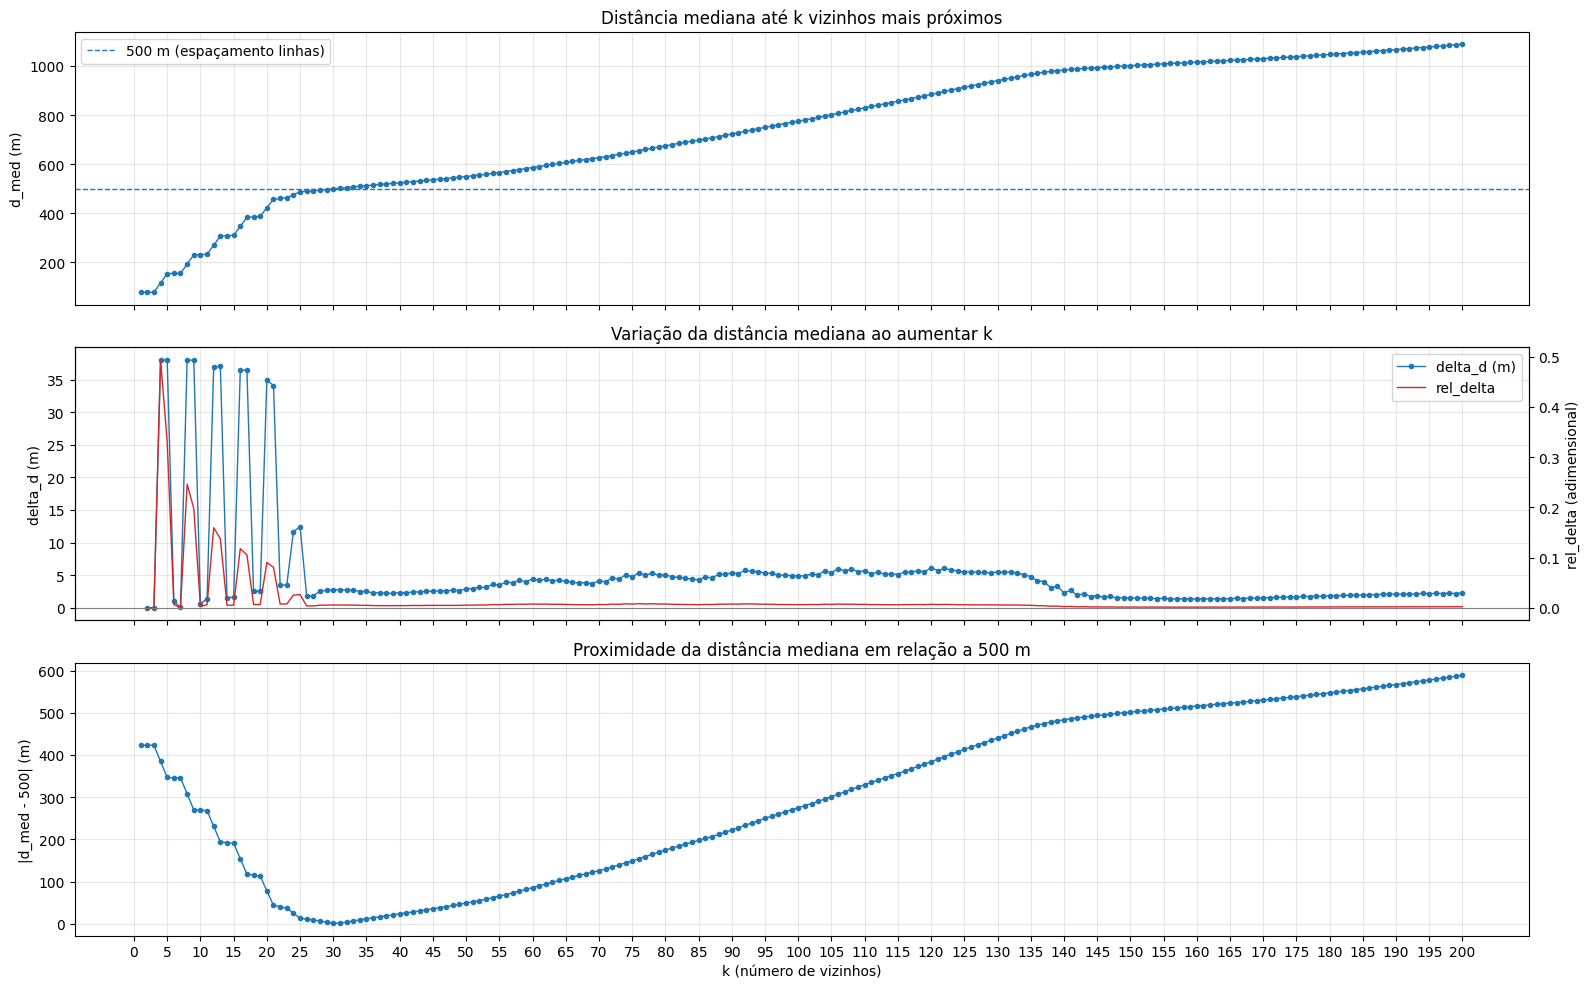

In [11]:
# Se quiser focar nos primeiros ks (por ex., até 100) para ficar mais legível:
k_max_plot = 200
df_plot = df_knn[df_knn["k"] <= k_max_plot].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1) d_med_m vs k
ax0 = axes[0]
ax0.plot(df_plot["k"], df_plot["d_med_m"], marker=".", linewidth=1)
ax0.axhline(500, linestyle="--", linewidth=1, label="500 m (espaçamento linhas)")
ax0.set_ylabel("d_med (m)")
ax0.set_title("Distância mediana até k vizinhos mais próximos")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper left")


# 2) delta_d vs k + rel_delta no eixo secundário
ax1 = axes[1]
ax1.plot(df_plot["k"], df_plot["delta_d"], marker=".", linewidth=1, label="delta_d (m)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_ylabel("delta_d (m)")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_plot["k"], df_plot["rel_delta"], color="tab:red", linewidth=1, label="rel_delta")
ax1b.set_ylabel("rel_delta (adimensional)")

# Construir uma legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Variação da distância mediana ao aumentar k")

# 3) abs_diff_200 vs k (pode usar escala log)
ax2 = axes[2]
ax2.plot(df_plot["k"], df_plot["abs_diff_500"], marker=".", linewidth=1)
ax2.set_ylabel("|d_med - 500| (m)")
ax2.set_xlabel("k (número de vizinhos)")
ax2.set_title("Proximidade da distância mediana em relação a 500 m")
ax2.grid(True, alpha=0.3)
ax1.set_xticks(np.arange(0, 201, 5))

# opcional: escalar em log se ficar muito comprimido
# ax2.set_yscale("log")

plt.tight_layout()
plt.show()


In [46]:
df_knn[20:30]

,d_med_m,delta_d,rel_delta,diff_to_500,abs_diff_500,ratio_to_500
k,,,,,,
21,456.039472,34.038279,0.080659,-43.960528,43.960528,0.912079
22,459.510888,3.471416,0.007612,-40.489112,40.489112,0.919022
23,463.009719,3.498831,0.007614,-36.990281,36.990281,0.926019
24,474.670823,11.661104,0.025185,-25.329177,25.329177,0.949342
25,487.119082,12.448259,0.026225,-12.880918,12.880918,0.974238
26,488.918194,1.799112,0.003693,-11.081806,11.081806,0.977836
27,490.764709,1.846516,0.003777,-9.235291,9.235291,0.981529
28,493.317610,2.552901,0.005202,-6.682390,6.682390,0.986635
29,496.004032,2.686422,0.005446,-3.995968,3.995968,0.992008


In [36]:
df[gamma_cols]

,ctcor_np,kperc_np,eu_np,eth_np,thk_razao,uth_razao,uk_razao
0,2623.547,1.217,3.089,33.034,27.005,0.088,2.366
1,698.633,0.455,1.072,7.603,16.425,0.133,2.178
2,590.052,0.299,0.596,7.660,25.027,0.064,1.592
3,592.809,0.660,0.887,5.556,8.388,0.107,0.898
4,1514.182,0.762,1.921,17.974,23.067,0.112,2.580
...,...,...,...,...,...,...,...
1391555,2662.809,1.250,1.417,35.628,28.296,0.055,1.564
1391556,3441.568,1.655,2.993,43.641,26.276,0.081,2.136
1391557,2323.832,1.702,2.310,25.868,15.286,0.100,1.535
1391558,2157.617,0.703,3.338,26.035,35.894,0.136,4.874


In [42]:
import numpy as np
import pandas as pd
import verde as vd

# -----------------------------------------
# 0) Configuração
# -----------------------------------------
# df: DataFrame com colunas x, y e as variáveis abaixo
vars_trend = [
    "ctcor_np",
    "kperc_np",
    "eu_np",
    "eth_np",
    "thk_razao",
    "uth_razao",
    "uk_razao",
    'mdt',
]

degrees = [0, 1, 2]
tol_r2 = 0.03  # tolerância em R² para aceitar graus mais simples

# limites máximos de grau por variável (critério físico)
max_degree = {
    "ctcor_np": 2,
    "kperc_np": 2,
    "eu_np":    2,
    "eth_np":   2,
    "thk_razao": 2,
    "uth_razao": 2,
    "uk_razao": 2,
    'mdt': 1,
}

x = df["x"].to_numpy()
y = df["y"].to_numpy()
coords_all = (x, y)

# -----------------------------------------
# 1) Avaliar R² e RMSE para cada grau
# -----------------------------------------
results = []

for var in vars_trend:
    y_all = df[var].to_numpy()
    mask = np.isfinite(y_all)
    xc, yc = coords_all[0][mask], coords_all[1][mask]
    z = y_all[mask]

    print(f"\n>>> {var}")
    for deg in degrees:
        trend = vd.Trend(degree=deg).fit((xc, yc), z)
        z_pred = trend.predict((xc, yc))

        ss_res = np.sum((z - z_pred) ** 2)
        ss_tot = np.sum((z - z.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot
        rmse = np.sqrt(ss_res / z.size)
        ncoef = trend.coef_.size

        print(f"  degree={deg}: R2={r2:.4f}, RMSE={rmse:.3f}, n_coef={ncoef}")

        results.append(
            {
                "var": var,
                "degree": deg,
                "r2": r2,
                "rmse": rmse,
                "ncoef": ncoef,
            }
        )

df_trend = pd.DataFrame(results)

# -----------------------------------------
# 2) Escolher grau "ótimo" por variável
#    (R² dentro de tol_r2 do máximo + limite físico)
# -----------------------------------------
def escolher_grau(grupo, tol=0.03):
    r2_max = grupo["r2"].max()
    candidatos = grupo[grupo["r2"] >= r2_max - tol]
    return candidatos.sort_values("degree").iloc[0]

best_by_var = (
    df_trend[["var", "degree", "r2", "rmse", "ncoef"]]
    .groupby("var", group_keys=False)
    .apply(escolher_grau, tol=tol_r2)
)

best_degree = best_by_var["degree"].to_dict()

final_degree = {
    var: min(best_degree[var], max_degree[var])
    for var in best_degree
}

print("\nGrau escolhido (numérico) por variável:")
print(best_by_var[["degree", "r2", "rmse"]])

print("\nGrau final após limites físicos:")
print(final_degree)

# -----------------------------------------
# 3) Ajustar Trend final e salvar resíduos
# -----------------------------------------
for var, deg in final_degree.items():
    y_all = df[var].to_numpy()
    mask = np.isfinite(y_all)
    xc, yc = coords_all[0][mask], coords_all[1][mask]
    z = y_all[mask]

    trend = vd.Trend(degree=deg).fit((xc, yc), z)
    regional = trend.predict((xc, yc))
    resid = z - regional

    col_res = f"{var}_res_deg{deg}"
    df.loc[mask, col_res] = resid

    print(f"{var}: degree={deg}, coef_shape={trend.coef_.shape}, resíduos -> coluna {col_res}")



>>> ctcor_np
  degree=0: R2=0.0000, RMSE=646.366, n_coef=1
  degree=1: R2=0.0428, RMSE=632.397, n_coef=3
  degree=2: R2=0.1234, RMSE=605.158, n_coef=6
  degree=3: R2=0.1741, RMSE=587.413, n_coef=10

>>> kperc_np
  degree=0: R2=0.0000, RMSE=0.312, n_coef=1
  degree=1: R2=0.0678, RMSE=0.301, n_coef=3
  degree=2: R2=0.0735, RMSE=0.300, n_coef=6
  degree=3: R2=0.0912, RMSE=0.297, n_coef=10

>>> eu_np
  degree=0: R2=0.0000, RMSE=1.011, n_coef=1
  degree=1: R2=0.0012, RMSE=1.011, n_coef=3
  degree=2: R2=0.0187, RMSE=1.002, n_coef=6
  degree=3: R2=0.0375, RMSE=0.992, n_coef=10

>>> eth_np
  degree=0: R2=0.0000, RMSE=9.943, n_coef=1
  degree=1: R2=0.0192, RMSE=9.847, n_coef=3
  degree=2: R2=0.0801, RMSE=9.536, n_coef=6
  degree=3: R2=0.1317, RMSE=9.265, n_coef=10

>>> thk_razao
  degree=0: R2=0.0000, RMSE=125.920, n_coef=1
  degree=1: R2=0.0242, RMSE=124.385, n_coef=3
  degree=2: R2=0.0263, RMSE=124.257, n_coef=6
  degree=3: R2=0.0331, RMSE=123.820, n_coef=10

>>> uth_razao
  degree=0: R2=0.0

/tmp/ipykernel_599014/2166359788.py:87: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(escolher_grau, tol=tol_r2)


ctcor_np: degree=2, coef_shape=(6,), resíduos -> coluna ctcor_np_res_deg2
eth_np: degree=2, coef_shape=(6,), resíduos -> coluna eth_np_res_deg2
eu_np: degree=2, coef_shape=(6,), resíduos -> coluna eu_np_res_deg2
kperc_np: degree=1, coef_shape=(3,), resíduos -> coluna kperc_np_res_deg1
mdt: degree=1, coef_shape=(3,), resíduos -> coluna mdt_res_deg1
thk_razao: degree=1, coef_shape=(3,), resíduos -> coluna thk_razao_res_deg1
uk_razao: degree=0, coef_shape=(1,), resíduos -> coluna uk_razao_res_deg0
uth_razao: degree=0, coef_shape=(1,), resíduos -> coluna uth_razao_res_deg0


In [48]:
import numpy as np
import verde as vd

# -----------------------------------------
# 0) Configuração
# -----------------------------------------
# df: contém x, y e as variáveis
vars_interp = [
    "ctcor_np",
    "kperc_np",
    "eu_np",
    "eth_np",
    "thk_razao",
    "uth_razao",
    "uk_razao",
    "mdt",
]

# já calculado anteriormente:
final_degree = {
    "ctcor_np": 2,
    "eth_np":   2,
    "eu_np":    2,
    "kperc_np": 1,
    "mdt":      1,
    "thk_razao": 1,
    "uk_razao": 0,
    "uth_razao": 0,
}

x_all = df["x"].to_numpy()
y_all = df["y"].to_numpy()
coords_all = (x_all, y_all)

# região e resoluções (ajuste conforme seu caso)
region_xy = vd.get_region(coords_all)   # (x_min, x_max, y_min, y_max)
spacing_block = df_knn.loc[26,'d_med_m']   # espaçamento para BlockReduce (m)
spacing_grid  = spacing_block * 10.0   # resolução do grid (m)

# -----------------------------------------
# 1) Função para construir o Chain por variável
# -----------------------------------------
def make_chain(var, spacing_block=spacing_block, mindist=spacing_grid):
    deg = final_degree[var]
    steps = []

    # etapa de decimação em blocos
    steps.append(
        ("reduce", vd.BlockReduce(np.median, spacing=spacing_block))
    )

    # etapa de trend: só entra se o grau > 0
    if deg > 0:
        steps.append(("trend", vd.Trend(degree=deg)))

    # etapa de interpolação
    steps.append(("spline", vd.Spline(mindist=mindist)))

    return vd.Chain(steps)

# -----------------------------------------
# 2) Ajustar o Chain e gerar o grid para cada variável
# -----------------------------------------
chains = {}
grids = {}

for var in vars_interp:
    z_all = df[var].to_numpy()
    mask = np.isfinite(z_all)

    coords = (x_all[mask], y_all[mask])
    data_var = z_all[mask]

    chain = make_chain(var)
    chain.fit(coords, data_var)
    chains[var] = chain

    # grid combinado (trend + spline) para esta variável
    grid = chain.grid(
        region=region_xy,
        spacing=spacing_grid,
        dims=["y", "x"],
        data_names=var,
    )
    grids[var] = grid

    print(f"{var}: degree={final_degree[var]}, grid gerado com shape {grid[var].shape}")


/tmp/ipykernel_599014/1779682135.py:57: FutureWarning: The mindist parameter of verde.Spline is no longer required and will be removed in Verde 2.0.0. Use the default value to obtain the future behavior.
  steps.append(("spline", vd.Spline(mindist=mindist)))
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7b0ac978a3e0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7b0ac978a3e0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current be

MemoryError: Unable to allocate 355. GiB for an array with shape (218273, 218273) and data type float64

In [ ]:
grid_ctcor = grids["ctcor_np"]
grid_mdt   = grids["mdt"]

# exemplo de plot rápido
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
grid_ctcor[var].plot()   # ou grid_ctcor["ctcor_np"].plot()
plt.title("ctcor_np (trend + spline)")
plt.show()
